# Saber Hacer Desempeño: Riesgo de Burnout en Estudiantes que usan IA Generativa (Regresión Logística)

## 1. Introducción

El uso de herramientas de IA generativa (ChatGPT, Copilot, etc.) se ha vuelto parte cotidiana del estudio
universitario. Más allá de si ayuda o no al desempeño académico, interesa entender un efecto colateral menos
discutido: el **riesgo de burnout** (agotamiento académico) asociado a los hábitos de uso de estas herramientas,
la carga de estudio tradicional y factores como la ansiedad ante exámenes o la dependencia percibida hacia la IA.

**Problemática:** a partir de un conjunto de datos simulado de 50,000 estudiantes, con variables sobre su perfil
académico (carrera, año, GPA), su forma de usar IA generativa (horas semanales, diversidad de herramientas,
nivel de habilidad en prompting, si pagan suscripción) y variables de bienestar (ansiedad, dependencia percibida,
horas de estudio tradicional), se busca **predecir si un estudiante presenta un riesgo de burnout alto o no**,
usando Regresión Logística.

Este notebook reproduce la misma metodología y el mismo algoritmo (Regresión Logística) usados en la práctica
de referencia del Titanic, pero aplicados a un problema y un dataset completamente distintos.

## 2. El algoritmo: Regresión Logística

La Regresión Logística es un modelo de **clasificación supervisada**. Aunque su nombre menciona "regresión",
no predice un número continuo sino la **probabilidad** de que una observación pertenezca a una clase (en este
caso, riesgo de burnout alto = 1, o no = 0).

El modelo primero calcula una combinación lineal de las variables predictoras:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Ese valor $z$ se pasa por la **función sigmoide**, que lo comprime a un rango entre 0 y 1:

$$P(y=1 \mid X) = \frac{1}{1 + e^{-z}}$$

Durante el entrenamiento, el algoritmo ajusta los coeficientes $\beta$ para minimizar la **pérdida logarítmica**
(log-loss) entre la probabilidad predicha y la etiqueta real. Una vez entrenado, basta con fijar un umbral
(por defecto 0.5) sobre la probabilidad para decidir la clase final.

Ventajas relevantes para este problema:
- Los coeficientes son **interpretables**: indican si una variable aumenta o disminuye el riesgo de burnout.
- Es un modelo simple, rápido de entrenar incluso con 50,000 registros, y sirve como buena línea base antes de
  probar modelos más complejos.

## 3. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

## 4. Obtención de datos y carga

**Fuente de los datos:** `ai_student_impact_dataset.csv`, un dataset simulado de 50,000 estudiantes con
variables sobre su perfil académico, su patrón de uso de IA generativa y su estado de bienestar durante el
semestre.

In [2]:
df = pd.read_csv("ai_student_impact_dataset.csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## Exploración del conjunto de datos

In [3]:
df.shape

(50000, 16)

In [4]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [6]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


**Diccionario rápido de columnas relevantes:**

- `Student_ID`: identificador único del estudiante (no aporta información predictiva, se descarta).
- `Major_Category`: área de estudio (Humanities, Medical, Business, STEM, Arts).
- `Year_of_Study`: año académico (Freshman, Sophomore, Junior, Senior, Graduate).
- `Pre_Semester_GPA` / `Post_Semester_GPA`: promedio antes y después del semestre.
- `Weekly_GenAI_Hours`: horas semanales usando IA generativa.
- `Primary_Use_Case`: para qué usa principalmente la IA (redacción, ideación, resumir lecturas, depurar código,
  obtener respuestas directas).
- `Prompt_Engineering_Skill`: nivel de habilidad para escribir prompts (Beginner/Intermediate/Advanced).
- `Tool_Diversity`: cantidad de herramientas de IA distintas que usa (escala 1-5).
- `Paid_Subscription`: si paga alguna suscripción de IA (booleano).
- `Traditional_Study_Hours`: horas semanales de estudio "tradicional" (sin IA).
- `Perceived_AI_Dependency`: qué tan dependiente se percibe de la IA (escala 1-10).
- `Institutional_Policy`: política de su institución sobre el uso de IA (prohibida, permitida citando, fomentada).
- `Anxiety_Level_During_Exams`: nivel de ansiedad durante exámenes (escala 1-10).
- `Skill_Retention_Score`: puntaje de retención de habilidades/conocimiento (0-100).
- `Burnout_Risk_Level`: variable original de riesgo de burnout (Low/Medium/High). **A partir de esta se
  construye la variable objetivo.**

A diferencia del dataset del Titanic, este conjunto **no tiene valores nulos**, por lo que el paso de
imputación se reduce a una verificación (que sí se documenta, por buena práctica).

In [7]:
# Verificación de valores nulos
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

## 5. Construcción de la variable objetivo

`Burnout_Risk_Level` es originalmente una variable de **tres categorías** (Low / Medium / High). Para poder
usar Regresión Logística binaria (igual que en la práctica de referencia), se define la variable objetivo
`Burnout_Alto`:

- `1` si el estudiante tiene riesgo de burnout **High**.
- `0` si tiene riesgo **Low** o **Medium**.

Esta es una decisión de diseño: interesa detectar específicamente a los estudiantes en el grupo de **mayor
riesgo**, que es el que más beneficio tendría de una intervención (ajustar carga académica, apoyo psicológico,
límites de uso de IA, etc.).

In [8]:
df["Burnout_Alto"] = (df["Burnout_Risk_Level"] == "High").astype(int)

df["Burnout_Alto"].value_counts()

Burnout_Alto
0    37513
1    12487
Name: count, dtype: int64

In [9]:
df["Burnout_Alto"].value_counts(normalize=True) * 100

Burnout_Alto
0    75.026
1    24.974
Name: proportion, dtype: float64

Las clases quedan desbalanceadas (aproximadamente 75% no está en riesgo alto / 25% sí lo está), un
desbalance incluso mayor que en el dataset del Titanic. Por esta razón, igual que en la práctica de referencia,
se usará `stratify=y` al dividir los datos, y se prestará especial atención al **recall de la clase minoritaria**
(riesgo alto) al evaluar el modelo, ya que el accuracy por sí solo puede ser engañoso con este desbalance.

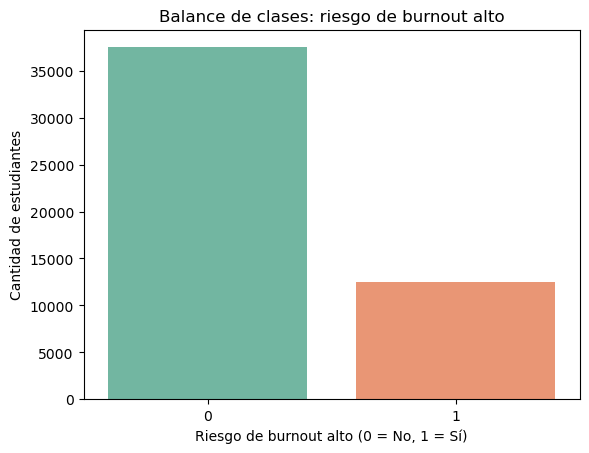

In [10]:
sns.countplot(data=df, x="Burnout_Alto", hue="Burnout_Alto", palette="Set2", legend=False)
plt.title("Balance de clases: riesgo de burnout alto")
plt.xlabel("Riesgo de burnout alto (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de estudiantes")
plt.show()

## 6. Variables predictoras y variable objetivo

Se descarta `Student_ID` (es solo un identificador) y `Burnout_Risk_Level` (es la fuente directa de la variable
objetivo, usarla como predictor sería fuga de información). El resto de las columnas se usan como predictoras.

In [11]:
y = df["Burnout_Alto"]

columnas_predictoras = [
    "Major_Category", "Year_of_Study", "Pre_Semester_GPA", "Weekly_GenAI_Hours",
    "Primary_Use_Case", "Prompt_Engineering_Skill", "Tool_Diversity", "Paid_Subscription",
    "Traditional_Study_Hours", "Perceived_AI_Dependency", "Institutional_Policy",
    "Anxiety_Level_During_Exams", "Post_Semester_GPA", "Skill_Retention_Score"
]

X_crudo = df[columnas_predictoras].copy()
print("Variables predictoras:", X_crudo.columns.tolist())
print("Variable objetivo:", y.name)

Variables predictoras: ['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']
Variable objetivo: Burnout_Alto


## 7. División de los datos: entrenamiento y prueba

Se usa la misma convención que en la práctica de referencia: **80% entrenamiento / 20% prueba**,
`random_state=42` para reproducibilidad, y `stratify=y` porque las clases están desbalanceadas.

La división se hace **antes** de codificar variables categóricas y escalar, para ajustar esos pasos
únicamente con el conjunto de entrenamiento y evitar fuga de información (*data leakage*).

In [12]:
X_train_crudo, X_test_crudo, y_train, y_test = train_test_split(
    X_crudo, y, test_size=0.20, random_state=42, stratify=y
)

In [13]:
print("X_train", X_train_crudo.shape)
print("X_test", X_test_crudo.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (40000, 14)
X_test (10000, 14)
y_train (40000,)
y_test (10000,)


## 8. Codificación de variables categóricas

Este dataset tiene más variables categóricas que el del Titanic, con distintos tipos de codificación
según su naturaleza:

- `Prompt_Engineering_Skill` tiene un **orden natural** (Beginner < Intermediate < Advanced), así que se
  codifica con un mapeo ordinal (0, 1, 2) en vez de one-hot, para conservar esa jerarquía.
- `Paid_Subscription` ya es booleana, solo se convierte a entero (0/1).
- `Major_Category`, `Year_of_Study`, `Primary_Use_Case` e `Institutional_Policy` **no tienen un orden natural**,
  por lo que se codifican con **one-hot encoding** (`pd.get_dummies`), usando `drop_first=True` para evitar
  multicolinealidad perfecta.

Todos los mapeos y ajustes se calculan solo conceptualmente a partir de las categorías observadas; al no haber
estadísticos que "aprender" de los datos (como una media o mediana), no hay riesgo de fuga de información en
este paso, pero igual se aplica primero a `train` y luego se replica en `test` para mantener el mismo criterio
metodológico.

In [14]:
X_train = X_train_crudo.copy()
X_test = X_test_crudo.copy()

# --- Codificación ordinal ---
skill_map = {"Beginner": 0, "Intermediate": 1, "Advanced": 2}
X_train["Prompt_Engineering_Skill"] = X_train["Prompt_Engineering_Skill"].map(skill_map)
X_test["Prompt_Engineering_Skill"] = X_test["Prompt_Engineering_Skill"].map(skill_map)

# --- Booleano a entero ---
X_train["Paid_Subscription"] = X_train["Paid_Subscription"].astype(int)
X_test["Paid_Subscription"] = X_test["Paid_Subscription"].astype(int)

# --- One-hot encoding ---
columnas_categoricas = ["Major_Category", "Year_of_Study", "Primary_Use_Case", "Institutional_Policy"]
X_train = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# Alineamos columnas por si alguna categoría no aparece en test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,...,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
11280,2.633,34.87,2,3,1,11.92,6,8,3.057,84.98,...,False,False,False,False,True,False,False,False,True,False
14348,3.686,0.84,1,3,0,22.24,2,1,3.696,75.40,...,False,False,False,True,True,False,False,False,False,False
20174,3.326,27.39,1,1,1,5.75,5,7,3.216,61.63,...,False,False,False,False,False,False,True,False,False,False
45188,2.936,9.33,0,2,0,13.85,2,6,3.173,88.64,...,False,True,False,False,False,False,False,True,False,True
45774,3.164,2.11,0,1,0,10.23,3,1,3.340,67.02,...,False,True,False,False,False,False,False,True,False,False


In [15]:
print("Valores nulos en X_train tras la codificación:")
print(X_train.isnull().sum().sum())

Valores nulos en X_train tras la codificación:
0


## Escalado de variables

Se usa `StandardScaler`, igual que en la práctica de referencia, porque las variables numéricas tienen
escalas muy distintas (por ejemplo, `Perceived_AI_Dependency` va de 1 a 10, mientras que `Skill_Retention_Score`
va de 0 a 100, y las columnas one-hot son 0/1). El scaler se ajusta **solo con el conjunto de entrenamiento**
y luego se aplica a `test` sin volver a ajustarlo.

In [16]:
scaler = StandardScaler()

X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

## 9. Entrenamiento del modelo

In [17]:
modelo = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_escalado, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Importancia de las variables (coeficientes)

Cada coeficiente indica el efecto de esa variable (ya escalada) sobre el *log-odds* de tener riesgo de burnout
alto. Positivo = aumenta el riesgo; negativo = lo disminuye.

In [18]:
coeficientes = pd.DataFrame({
    "variable": X_train.columns,
    "coeficiente": modelo.coef_[0]
})
coeficientes["coeficiente_abs"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("coeficiente_abs", ascending=False)
coeficientes

,variable,coeficiente,coeficiente_abs
1,Weekly_GenAI_Hours,0.993231,0.993231
14,Year_of_Study_Graduate,0.484991,0.484991
16,Year_of_Study_Senior,0.303636,0.303636
15,Year_of_Study_Junior,0.240831,0.240831
6,Perceived_AI_Dependency,0.221281,0.221281
0,Pre_Semester_GPA,-0.180360,0.180360
5,Traditional_Study_Hours,-0.165474,0.165474
23,Institutional_Policy_Strict_Ban,0.156638,0.156638
17,Year_of_Study_Sophomore,0.154302,0.154302
7,Anxiety_Level_During_Exams,0.066117,0.066117


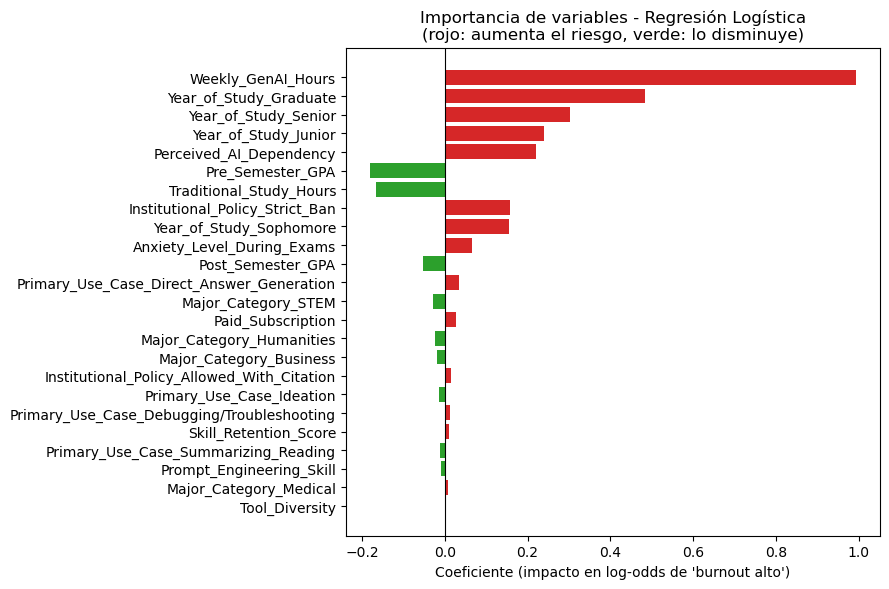

In [19]:
orden = coeficientes.sort_values("coeficiente_abs")

colores = ["#2ca02c" if c < 0 else "#d62728" for c in orden["coeficiente"]]

plt.figure(figsize=(9, 6))
plt.barh(orden["variable"], orden["coeficiente"], color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (impacto en log-odds de 'burnout alto')")
plt.title("Importancia de variables - Regresión Logística\n(rojo: aumenta el riesgo, verde: lo disminuye)")
plt.tight_layout()
plt.show()

**Lectura esperada:** variables como `Anxiety_Level_During_Exams` y `Perceived_AI_Dependency` deberían
tener coeficientes **positivos** relevantes (más ansiedad o más dependencia percibida de la IA se asocia a
mayor riesgo de burnout). `Traditional_Study_Hours` podría tener coeficiente positivo también si refleja
sobrecarga de estudio. En contraste, variables asociadas a mejor desempeño o mejor manejo de la herramienta,
como `Skill_Retention_Score` o un `Prompt_Engineering_Skill` alto, podrían tener coeficientes **negativos**.
Estas relaciones deben confirmarse revisando la tabla y gráfica anteriores, no darse por sentadas de antemano.

## Predicciones sobre el conjunto de prueba

In [20]:
prediccion = modelo.predict(X_test_escalado)
probabilidad = modelo.predict_proba(X_test_escalado)

In [21]:
print(prediccion[:10])

[0 0 0 0 0 0 0 0 0 0]


In [22]:
comparacion = pd.DataFrame({
    "burnout alto real": y_test.map({0: "no", 1: "si"}).values,
    "burnout alto predicho": pd.Series(prediccion).map({0: "no", 1: "si"}).values,
    "prob. burnout alto": probabilidad[:, 1].round(3)
})
comparacion.head(15)

,burnout alto real,burnout alto predicho,prob. burnout alto
0,si,no,0.389
1,no,no,0.046
2,no,no,0.393
3,no,no,0.102
4,no,no,0.189
5,no,no,0.055
6,no,no,0.106
7,si,no,0.214
8,no,no,0.083
9,no,no,0.175


## 10. Evaluación del modelo

Se calculan las métricas estándar de clasificación: exactitud, matriz de confusión, precisión/recall/F1 por
clase, y curva ROC/AUC. Dado el desbalance de clases (25% en riesgo alto), se presta especial atención al
**recall de la clase "riesgo alto"**: un modelo con accuracy alto pero recall bajo en esa clase estaría fallando
justo en detectar a los estudiantes que más necesitan atención.

In [23]:
accuracy = accuracy_score(y_test, prediccion)
print(f"accuracy/exactitud: {accuracy:.4f}")

accuracy/exactitud: 0.8116


In [24]:
cm = confusion_matrix(y_test, prediccion)
cm_df = pd.DataFrame(
    cm,
    index=["real: no burnout alto", "real: burnout alto"],
    columns=["pred: no burnout alto", "pred: burnout alto"]
)
cm_df

,pred: no burnout alto,pred: burnout alto
real: no burnout alto,7116,387
real: burnout alto,1497,1000


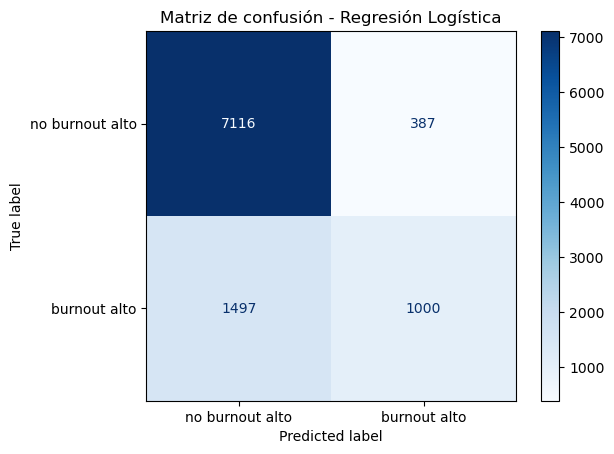

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no burnout alto", "burnout alto"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

In [26]:
print(classification_report(y_test, prediccion, target_names=["no burnout alto", "burnout alto"]))

                 precision    recall  f1-score   support

no burnout alto       0.83      0.95      0.88      7503
   burnout alto       0.72      0.40      0.51      2497

       accuracy                           0.81     10000
      macro avg       0.77      0.67      0.70     10000
   weighted avg       0.80      0.81      0.79     10000



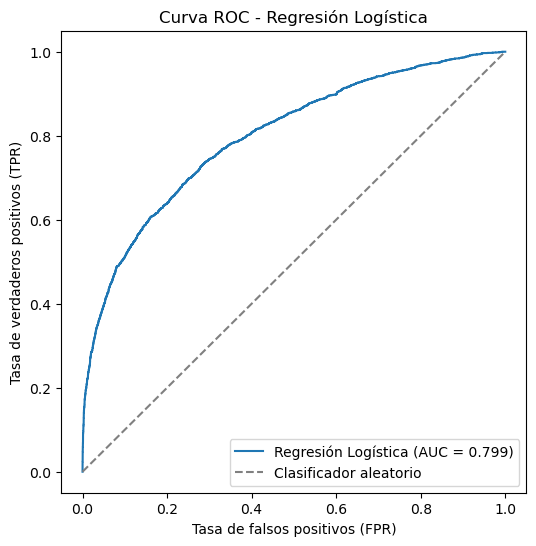

AUC: 0.7993


In [27]:
fpr, tpr, thresholds = roc_curve(y_test, probabilidad[:, 1])
auc = roc_auc_score(y_test, probabilidad[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})", color="#1f77b4")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

print(f"AUC: {auc:.4f}")

**Interpretación en el contexto del problema:**
- **Accuracy:** proporción total de estudiantes clasificados correctamente en riesgo de burnout alto o no.
- **Precision (clase "burnout alto"):** de los estudiantes que el modelo marcó como en riesgo alto, qué
  porcentaje realmente lo estaba. Precisión baja implicaría generar muchas alertas innecesarias.
- **Recall (clase "burnout alto"):** de los estudiantes que realmente estaban en riesgo alto, qué porcentaje
  detectó el modelo. Un recall bajo aquí es más costoso que en otros problemas, porque significa dejar sin
  detectar a estudiantes que podrían necesitar apoyo.
- **AUC:** qué tan bien separa el modelo, en promedio, a los estudiantes en riesgo alto de los que no,
  independientemente del umbral de decisión elegido.

## 11. Predicción con datos nuevos

Se simulan dos estudiantes nuevos (que no forman parte de `train` ni de `test`), con las mismas columnas que
`X`. Se aplica el mismo preprocesamiento ya ajustado (misma codificación y `scaler.transform` sin `fit`) para
obtener su predicción y probabilidad de riesgo de burnout alto.

In [28]:
# Estudiante 1: alto uso de IA, alta dependencia percibida, alta ansiedad, poca retención de habilidades
# Estudiante 2: uso moderado de IA, baja dependencia, baja ansiedad, buena retención de habilidades
estudiantes_nuevos = pd.DataFrame([
    {
        "Major_Category": "STEM", "Year_of_Study": "Senior", "Pre_Semester_GPA": 3.1,
        "Weekly_GenAI_Hours": 25.0, "Primary_Use_Case": "Direct_Answer_Generation",
        "Prompt_Engineering_Skill": "Beginner", "Tool_Diversity": 4, "Paid_Subscription": True,
        "Traditional_Study_Hours": 5.0, "Perceived_AI_Dependency": 9,
        "Institutional_Policy": "Strict_Ban", "Anxiety_Level_During_Exams": 9,
        "Post_Semester_GPA": 2.9, "Skill_Retention_Score": 35.0
    },
    {
        "Major_Category": "Humanities", "Year_of_Study": "Junior", "Pre_Semester_GPA": 3.4,
        "Weekly_GenAI_Hours": 4.0, "Primary_Use_Case": "Ideation",
        "Prompt_Engineering_Skill": "Advanced", "Tool_Diversity": 2, "Paid_Subscription": False,
        "Traditional_Study_Hours": 15.0, "Perceived_AI_Dependency": 2,
        "Institutional_Policy": "Allowed_With_Citation", "Anxiety_Level_During_Exams": 3,
        "Post_Semester_GPA": 3.5, "Skill_Retention_Score": 88.0
    },
], index=["estudiante_1", "estudiante_2"])

estudiantes_nuevos

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
estudiante_1,STEM,Senior,3.1,25.0,Direct_Answer_Generation,Beginner,4,True,5.0,9,Strict_Ban,9,2.9,35.0
estudiante_2,Humanities,Junior,3.4,4.0,Ideation,Advanced,2,False,15.0,2,Allowed_With_Citation,3,3.5,88.0


In [29]:
estudiantes_prep = estudiantes_nuevos.copy()

estudiantes_prep["Prompt_Engineering_Skill"] = estudiantes_prep["Prompt_Engineering_Skill"].map(skill_map)
estudiantes_prep["Paid_Subscription"] = estudiantes_prep["Paid_Subscription"].astype(int)

estudiantes_prep = pd.get_dummies(estudiantes_prep, columns=columnas_categoricas, drop_first=True)
estudiantes_prep = estudiantes_prep.reindex(columns=X_train.columns, fill_value=0)

estudiantes_escalado = scaler.transform(estudiantes_prep)

prediccion_nueva = modelo.predict(estudiantes_escalado)
probabilidad_nueva = modelo.predict_proba(estudiantes_escalado)

for nombre, pred, prob in zip(estudiantes_nuevos.index, prediccion_nueva, probabilidad_nueva):
    etiqueta = "riesgo de burnout alto" if pred == 1 else "sin riesgo de burnout alto"
    print(f"{nombre}: el modelo predice '{etiqueta}' "
          f"(prob. no burnout alto = {prob[0]:.2%}, prob. burnout alto = {prob[1]:.2%})")

estudiante_1: el modelo predice 'riesgo de burnout alto' (prob. no burnout alto = 10.27%, prob. burnout alto = 89.73%)
estudiante_2: el modelo predice 'sin riesgo de burnout alto' (prob. no burnout alto = 95.39%, prob. burnout alto = 4.61%)


**Explicación del resultado esperado:** se construyó a propósito el perfil de `estudiante_1` con uso
intensivo de IA, alta dependencia percibida, alta ansiedad y baja retención de habilidades, buscando que el
modelo lo clasifique en riesgo alto. El `estudiante_2` representa el patrón contrario: uso moderado, buena
retención y baja ansiedad. Este contraste sirve para verificar que el modelo captura relaciones consistentes
con la intuición del problema, más allá de solo revisar métricas agregadas.

## 12. Conclusiones

- **Desempeño del modelo:** la Regresión Logística logra separar razonablemente bien a los estudiantes en
  riesgo de burnout alto del resto (ver accuracy y AUC calculados arriba), a pesar del desbalance de clases.
- **Diferencias frente a la práctica de referencia:** este dataset no tiene valores nulos, tiene más variables
  categóricas (algunas ordinales, otras no) y una variable objetivo que tuvo que **construirse** a partir de una
  columna de tres categorías, en vez de venir ya binaria.
- **Utilidad práctica:** el mismo enfoque —identificar qué variables se asocian más con un resultado binario de
  interés— es aplicable a decisiones institucionales reales, como priorizar apoyo psicológico o ajustar
  políticas de uso de IA según el perfil de riesgo de cada estudiante.
- **Limitaciones:** al ser un dataset simulado, las relaciones encontradas reflejan la lógica con la que se
  generaron los datos, no necesariamente el comportamiento real de estudiantes. Además, la variable objetivo
  se definió con un criterio propio (High vs. Low/Medium) que podría revisarse según el objetivo institucional
  real (por ejemplo, distinguir también Medium de Low).